2. Data Visualization from Extraction Transformation and Loading (ETL) Process 

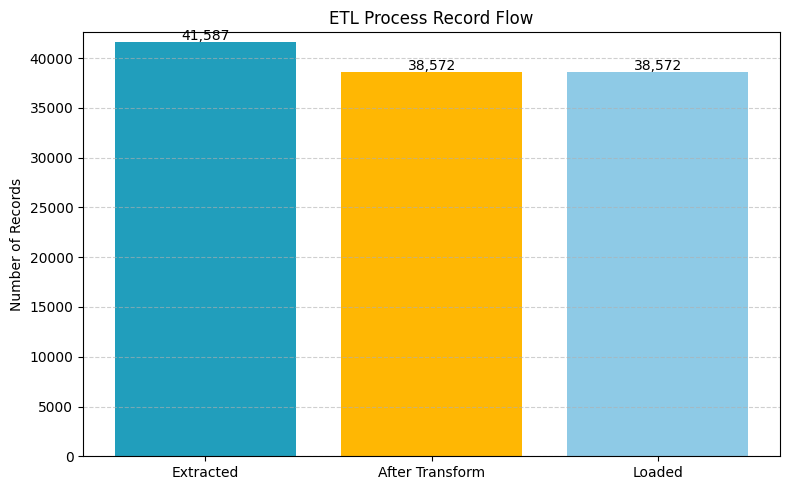

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

#LOAD DATA
file_path = "Ecommerce+Sales+Data.xlsx"  
excel_file = pd.ExcelFile(file_path)

#EXTRACT
sheet_name = excel_file.sheet_names[0] 
df = excel_file.parse(sheet_name)

df

#TRANSFORM
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

df

# Check missing values before transformation
nulls_before = df.isnull().sum()
rows_before = len(df)
nulls_before

# Drop rows with any nulls (cleaning)
df_cleaned = df.dropna()
df_cleaned

nulls_after = df_cleaned.isnull().sum()
rows_after = len(df_cleaned)
rows_after

#Load
df_cleaned.to_csv("Cleaned_Ecommerce_Data.csv", index=False)

stages = ['Extracted', 'After Transform', 'Loaded']
record_counts = [rows_before, rows_after, rows_after]
colors = ['#219ebc', '#ffb703', '#8ecae6']

#VISUALIZATION
plt.figure(figsize=(8, 5))
plt.bar(stages, record_counts, color=colors)
plt.title('ETL Process Record Flow')
plt.ylabel('Number of Records')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, rows_before + 1000)
for i, count in enumerate(record_counts):
    plt.text(i, count + 200, f"{count:,}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()